In [2]:
pip install -r requirements.txt


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("../Data/batch-1-10.csv")
df = df.rename(columns={
"Time (h)": "time",
"Aeration rate(Fg:L/h)": "aeration",
"Agitator RPM(RPM:RPM)": "rpm",
"Sugar feed rate(Fs:L/h)": "feed_rate",
"Dissolved oxygen concentration(DO2:mg/L)": "do",
"Penicillin concentration(P:g/L)": "penicillin",
"Offline Biomass concentratio(X_offline:X(g L^{-1}))": "biomass",
"Carbon evolution rate(CER:g/h)": "cer",
"Oxygen Uptake Rate(OUR:(g min^{-1}))": "our",
"Temperature(T:K)": "temp",
"pH(pH:pH)": "ph"
})
df.head()

,time,aeration,rpm,feed_rate,Acid flow rate(Fa:L/h),Base flow rate(Fb:L/h),Heating/cooling water flow rate(Fc:L/h),Heating water flow rate(Fh:L/h),Water for injection/dilution(Fw:L/h),Air head pressure(pressure:bar),...,our,Oxygen in percent in off-gas(O2:O2 (%)),Offline Penicillin concentration(P_offline:P(g L^{-1})),biomass,cer,Ammonia shots(NH3_shots:kgs),Viscosity(Viscosity_offline:centPoise),Fault reference(Fault_ref:Fault ref),0 - Recipe driven 1 - Operator controlled(Control_ref:Control ref),batch_id
0,0.2,30,100,8,0.0000,30.118,9.8335,0.0001,0,0.6,...,0.480510,0.19595,NaN,NaN,0.034045,0,NaN,0,0,1
1,0.4,30,100,8,0.0000,51.221,18.1550,0.0001,0,0.6,...,0.058147,0.20390,NaN,NaN,0.038702,0,NaN,0,0,1
2,0.6,30,100,8,0.0000,54.302,9.5982,0.0001,0,0.6,...,-0.041505,0.20575,NaN,NaN,0.040240,0,NaN,0,0,1
3,0.8,30,100,8,0.0000,37.816,4.3395,0.0001,0,0.6,...,-0.056737,0.20602,NaN,NaN,0.041149,0,NaN,0,0,1
4,1.0,30,100,8,0.5181,18.908,1.1045,0.0001,0,0.6,...,-0.049975,0.20589,1.017800e-25,0.52808,0.041951,0,4.083,0,0,1


Text(0.5, 1.0, 'Time step size')

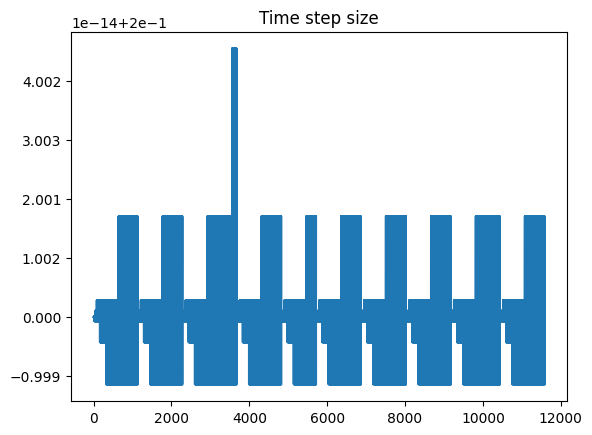

In [5]:
df["dt"] = df.groupby("batch_id")["time"].diff()
plt.plot(df["dt"])
plt.title("Time step size")
#time step is constant at 0.2

In [ ]:
df["dt"] = 0.2 #remove noise

Text(0.5, 1.0, 'Cumulative substrate feed per batch')

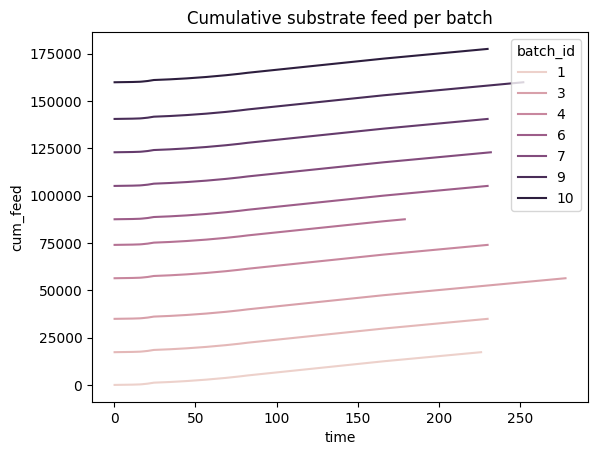

In [14]:
df["cum_feed"] = (df["feed_rate"] * df["dt"]).cumsum()
sns.lineplot(data=df, x="time", y="cum_feed", hue="batch_id")
plt.title("Cumulative substrate feed per batch")
#shows that batch feed was done continously measured, not batchwise

In [ ]:
#YO BIOMASS IS ALMOST ENTIRELY NaN


,time,aeration,rpm,feed_rate,Acid flow rate(Fa:L/h),Base flow rate(Fb:L/h),Heating/cooling water flow rate(Fc:L/h),Heating water flow rate(Fh:L/h),Water for injection/dilution(Fw:L/h),Air head pressure(pressure:bar),...,biomass,cer,Ammonia shots(NH3_shots:kgs),Viscosity(Viscosity_offline:centPoise),Fault reference(Fault_ref:Fault ref),0 - Recipe driven 1 - Operator controlled(Control_ref:Control ref),batch_id,dt,cum_feed,growth_rate
0,0.2,30,100,8,0.0000,30.1180,9.8335,0.0001,0,0.6,...,NaN,0.034045,0,NaN,0,0,1,0.2,1.6,NaN
1,0.4,30,100,8,0.0000,51.2210,18.1550,0.0001,0,0.6,...,NaN,0.038702,0,NaN,0,0,1,0.2,3.2,NaN
2,0.6,30,100,8,0.0000,54.3020,9.5982,0.0001,0,0.6,...,NaN,0.040240,0,NaN,0,0,1,0.2,4.8,NaN
3,0.8,30,100,8,0.0000,37.8160,4.3395,0.0001,0,0.6,...,NaN,0.041149,0,NaN,0,0,1,0.2,6.4,NaN
4,1.0,30,100,8,0.5181,18.9080,1.1045,0.0001,0,0.6,...,0.52808,0.041951,0,4.083,0,0,1,0.2,8.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11580,229.2,65,100,80,0.0000,17.7970,22.8130,93.4870,250,0.9,...,NaN,1.113700,0,NaN,0,0,10,0.2,177446.0,NaN
11581,229.4,65,100,80,0.0000,17.9450,71.0210,9.3487,250,0.9,...,NaN,1.113100,0,NaN,0,0,10,0.2,177462.0,NaN
11582,229.6,65,100,80,0.0000,15.4730,21.3060,156.6800,250,0.9,...,NaN,1.112500,0,NaN,0,0,10,0.2,177478.0,NaN
11583,229.8,65,100,80,0.0000,12.1100,125.6700,15.6680,250,0.9,...,NaN,1.111900,0,NaN,0,0,10,0.2,177494.0,NaN
